Author: Robin Sternberg  
This notebook is licensed under Creative Commons Attribution-ShareAlike 4.0

# Problembeschreibung

Die Debatten im Bundestag sind oft hitzig und laut. Dass es ziemlich viele Zwischenrufe gibt, wurde schon in der statistischen Analyse klar. Aber nicht alle Zwischenrufe sind negativ.  
Zusätzlich zu den negativen Zwischenrufen gibt es auch Bekräftigung aus der eigenen Fraktion oder Koalition.  
Deswegen versuche ich mit den Notebooks in diesem Ordner die verschiedenen Arten von Zwischenrufen im Bundestag zu hinsichtlich ihres Sentiments zu analysieren.  

Dieses Notebook spezialisiert sich (hauptsächlich) auf klassische Machine-Learning Modelle, wie den Naive Bayes Klassifikator und Support Vector Machines und enthält am Ende noch die Kombination von BERT-Embeddings mit einer SVM zur Klassifikation.

# Einordnung in Taxonomie der Sentiment Analyse

![](../_img_resources/sentiment_taxonomy.png)

Ich würde den hier im Notebook gelieferten Task als Opinion Polarity Classification einordnen. Allerdings haben unsere Daten die Besonderheit, dass viele der Zwischenrufe in herkömmlichen Kontexten als negativ gelten würden, einfach nur, weil sie dem Redner widersprechen. Der Bundestag ist aber ein Parlament und in einem Parlament wird nun einmal miteinander diskutiert. Deswegen ist der Grundton schon etwas kritischer. Uns interessieren deswegen im negativen Bereich eher die Aussagen, die den Redner, dessen Partei, oder dessen Politik klar angreifen. Dabei fallen dann Aussagen raus, die den Redner nur vergleichsweise sachlich verbessern (aus Sicht des Unterbrechers).

# Labeling

Das Labeling für die Daten hat sich als schwerer als gedacht herausgestellt. Wir waren uns an vielen Stellen unsicher, ob eine Unterbrechung negatives, oder neutrales Sentiment enthält.  
Zu den Daten muss man sagen, dass  
    a) wie in der statistischen Analyse gezeigt, die meisten Unterbrechungen mit '!' enden, was jede Aussage in positive oder negative Richtung verstärkt und  
    b) die Abgeordneten eher selten etwas hineinrufen, wenn sie nicht noch eine Aussage des Redners korrigieren wollen. 
Diese Kombination macht es schwierig, den Daten einheitlich Labels zu geben.   
Hier ein paar Beispiele:
1. > Es war so eine schöne Rede!   

    Man könnte meinen, der Satz drückt die positive Einstellung des Unterbrechers/der Unterbrecherin aus, aber wenn man in den Kontext hineinschaut, sieht man direkt, dass das Gegenteil der Fall ist.
    Hier wollte Wolfgang Roth (SPD) darauf hinweisen, dass die Rede schön **war** und sie es jetzt aber nicht mehr ist, weil der Redner Helmut Haussmann (FDP) keine Ratschläge der Sozialdemokraten annehmen will und sagt, dass er/seine Fraktion diese nicht braucht.  
    Das Sentiment, das in der Aussage enthalten ist, ist also negativ.  

2. > Sie sind immer wieder gut!

    Das hier ist ein Standard-Fall von Sarkasmus.  
    Der Abgeordnete Sebastian Münzenmaier (AfD) wollte der SPD-Abgeordneten Helge Lindh leider kein Kompliment zu ihrer Arbeit machen.

3. > Das ist doch positiv!  

    Hier widerspricht Eva-Maria Kors (CDU/CSU) ihrer Kollegin Hildegard Wester (SPD) in einer Aussage zum Mutterschutz.  
    (Anmerkung: Das Beispiel hat mich an die Beispiele zu den Grenzen von wörterbuch-basierten Ansätzen aus der Vorlesung erinnert)  

4. > Das ist eine freie Entscheidung!
5. > Wir werden Sie beim Wort nehmen!
6. > Vier Tage Anhörung!

    Auch als Mensch kann man bei Beispielen 4-6 ohne Kontext nur raten. Außerdem ist selbst mit Kontext fragwürdig, ob ein `Wir werden Sie beim Wort nehmen!` einfach nur eine respektvolle Herausforderung an die Redner-Partei ist, oder ob der Satz wirklich negatives Sentiment enthält.
    Diese Kontext-Abhängigkeien und die generell kritische Grundstimmung in Diskussionen führen dazu, dass die Unterscheidung zwischen den Labels schwierig ist.  

### Prozess
Zum Labeling habe ich ein kleines Kommandozeilen-Skript geschrieben, in dem man sich durch eine noch ungelabelte CSV-Datei durcharbeiten kann.  
Dann haben wir die Arbeit in der Projektgruppe aufgeteilt und jeder hat 1000 Zwischenrufe annotiert.  
Während des Finetunings von BERT habe ich selbst noch einmal 1500 Zwischenrufe gelabelt. Insgesamt sind wir also bei 4500 gelabelten Zwischenrufen.  
Das Skript ist unter senti_labeling.py zu finden.

### Unsere Konventionen

Wir haben uns in der Gruppe dafür geeinigt, dass wir bei reinem Widerspruch, ohne persönlichen Angriff auf den Redner oder die Partei, das Label 'neutral' vergeben.  
Auch Sarkasmus, der ohne Kontext nicht ersichtlich ist, erhält das Label neutral (anders bei klar überzogenen Aussagen).
Das hat mehrere Gründe.
1. Die spätere Klassifikation durch das Modell soll aus Gründen der Performanz nur auf dem Text des Zwischenrufs basieren und nicht den Kontext miteinbeziehen. Das Modell soll ja alle Zwischenrufe seit 1991 einordnen.
2. Uns sind vor allem die Unterbrechungen wichtig, bei denen der Unterbrecher relativ klar aufgebracht oder zustimmend ist. Dadurch, dass wir lieber etwas mehr fragwürdige Labels auf neutral setzen, liefert das Modell am Ende auch zuverlässigere Ergebnisse (höhere precision) auf den anderen beiden Kategorien. So zumindest der Gedankengang.

# Daten laden

In [11]:
import pandas as pd
pd.options.mode.chained_assignment = None  # get rid of SettingWithCopywarning
import numpy as np
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import plotly.express as px

rand_seed = 42

In [2]:
df_interruptions_labeled = pd.read_parquet('../_data/interruptions_labeled.parquet')
df_interruptions_labeled = df_interruptions_labeled.rename(columns={'sentiment': 'label', 'comment_text':'text'})
df_interruptions_labeled.sample(5, random_state=rand_seed)

,Unnamed: 0,text,comment_party,comment_name,interrupted_speaker_party,interrupted_speaker,date,speech_id,preceding_context,label
2323,2323,Das gehört zur Landespolizei!,CDU/CSU,Max Straubinger,GRÜNE,Katrin Göring-Eckardt,2016-01-13,136027,"rren. Es kommt darauf an, dass wir klarmachen:...",0
3686,337786,Das ist gut!,FDP,Christine Aschenberg-Dugnus,CDU/CSU,Jens Spahn,2018-10-18,152586,"ge senken, im Übrigen, über die Parität hinaus...",2
2974,2974,Er hat eben gar nicht zugehört!,FDP,Dirk Niebel,CDU/CSU,Dr. Ralf Brauksiepe,2009-07-03,95327,"n, die es können, um zwei Jahre zu verlängern,...",1
2992,2992,Das kann man doch nicht ernst nehmen!,GRÜNE,Britta Haßelmann,CDU/CSU,Andreas Mattfeldt,2022-11-25,187928,"trahlung auf Forschung, mit Ausstrahlung auf B...",1
468,468,Steuersenkung auf Pump!,SPD,Thomas Oppermann,FDP,Rainer Brüderle,2012-05-10,113731,"ung steht!) Wo Gabriel kuscheln müsste, macht ...",1


In [3]:
df_relevant = df_interruptions_labeled[['text', 'label']]
df_relevant.head()

,text,label
0,Weiß das das Jugendamt?,1
1,Wieso?,0
2,Erasmus,0
3,Sehr richtig!,2
4,Sie aber auch nicht!,1


In [4]:
id2label = {0:'neutral', 1:'negative', 2:'positive'}
df_relevant['label_txt'] = df_relevant['label'].map(id2label)
df_relevant.head()

,text,label,label_txt
0,Weiß das das Jugendamt?,1,negative
1,Wieso?,0,neutral
2,Erasmus,0,neutral
3,Sehr richtig!,2,positive
4,Sie aber auch nicht!,1,negative


In [13]:

label_counts = df_relevant['label_txt'].value_counts()
# Creating the bar plot using plotly
fig = px.bar(label_counts, 
             x=label_counts.index, 
             y=label_counts.values, 
             labels={'index': 'Sentiment Label', 'y': 'Anzahl von Zwischenrufen'},
             title='Histogramm der Zwischenrufe nach Sentiment-Label',)

# Updating layout for better readability
fig.update_layout(xaxis_title='Sentiment Label',
                  yaxis_title='Anzahl von Zwischenrufen')

# Show the figure
fig.show()

Wie unschwer zu erkennen ist, ist die Klassenverteilung recht schief. Vor allem positive Samples sind vergleichsweise wenig vertreten.  
Da in unserer Analyse vor allem positive und negative interessant sind, müssen wir uns bei den Evaluationsscores wohl mehr auf Precision, Recall und F1-Score konzentrieren. 

# Naive Bayes

Den Naive Bayes Klassifikator habe ich als erstes herangezogen, damit ich ein Gefühl dafür bekomme, welche Scores auf unseren Daten auch ohne übermäßig komplexe Modelle erreichbar sind.  
Er dient sozusagen als Benchmark

In [5]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, accuracy_score
from sklearn.naive_bayes import MultinomialNB

In [6]:
X, y = df_relevant['text'], df_relevant['label']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=rand_seed)
y_test_txt = [id2label[y] for y in y_test]

In [7]:
vectorizer = TfidfVectorizer()
vectorizer.fit(X)
X_train_tfidf = vectorizer.transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [8]:
nb_classifier = MultinomialNB()
nb_classifier.fit(X_train_tfidf, y_train)

MultinomialNB()

In [9]:
y_pred_tfidf = nb_classifier.predict(X_test_tfidf)
y_pred_tfidf_txt = [id2label[y] for y in y_pred_tfidf]

In [10]:
print(classification_report(y_test_txt, y_pred_tfidf_txt, zero_division=0))

              precision    recall  f1-score   support

    negative       0.84      0.33      0.47       266
     neutral       0.70      0.97      0.81       518
    positive       0.94      0.57      0.71       116

    accuracy                           0.73       900
   macro avg       0.83      0.62      0.67       900
weighted avg       0.77      0.73      0.70       900



Die Klassifikation der Zwischenrufe zeigt eine hohe Präzision für positive und negative Labels, aber der Recall ist ziemlich schlecht. Vor allem für negative Zwischenrufe. Da erreicht er nur 33%.

### Switch von TFIDF auf normale Term Frequency

In [11]:
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer()
count_vectorizer.fit(X)
X_train_count = count_vectorizer.transform(X_train) # build vocab on the whole labeled dataset
X_test_count = count_vectorizer.transform(X_test)

# naive Bayes classification
nb_classifier_no_tfidf = MultinomialNB()
nb_classifier_no_tfidf.fit(X_train_count, y_train)

y_pred_no_tfidf = nb_classifier_no_tfidf.predict(X_test_count)

# evaluation
y_pred_no_tfidf_txt = [id2label[y] for y in y_pred_no_tfidf]
report_no_tfidf = classification_report(y_test_txt, y_pred_no_tfidf_txt, zero_division=0)

print(report_no_tfidf)

              precision    recall  f1-score   support

    negative       0.69      0.55      0.61       266
     neutral       0.76      0.86      0.81       518
    positive       0.78      0.66      0.71       116

    accuracy                           0.74       900
   macro avg       0.74      0.69      0.71       900
weighted avg       0.74      0.74      0.74       900



Interessanterweise haben sich die f1-Scores bei der Nutzung des normalen Count Vectorizers etwas verbessert. Richtig gut sind die Ergebnisse aber immer noch nicht.  
In der Verwechslungsmatrix sieht man, dass vor allem negative labels oft der neutralen Klasse zugeordnet werden.

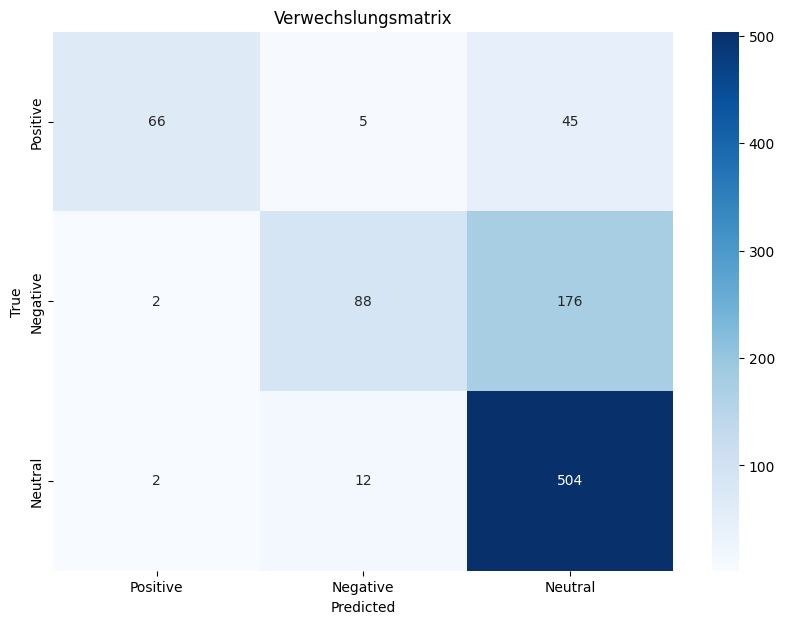

In [24]:
cm_svm = confusion_matrix(y_test, y_pred_tfidf, labels = [2,1,0]) # confusion matrix. labels = [...] for consistent ordering across notebooks
plt.figure(figsize=(10,7))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', xticklabels=['Positive', 'Negative', 'Neutral'], yticklabels=['Positive', 'Negative', 'Neutral'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Verwechslungsmatrix')
plt.show()

# Support Vector Machines

Als etwas komplexeren Classifier, habe ich mich für die SVM entschieden. Die kommt gut mit hochdimensionalen Daten klar, was bei TFIDF-Vektoren mit mehreren tausend Einträgen von Vorteil ist.

In [15]:
from sklearn.svm import SVC

In [16]:
X = df_relevant["text"]
y = df_relevant["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=rand_seed)

In [17]:
tfidf_vectorizer = TfidfVectorizer()
tfidf_vectorizer.fit(X) # build vocab on the whole labeled dataset
X_train_tfidf = tfidf_vectorizer.transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [18]:
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(3600, 4074)
(900, 4074)


### Standard Konfiguration

In [19]:
svm_classifier = SVC(kernel='linear', random_state=rand_seed)
svm_classifier.fit(X_train_tfidf, y_train)

SVC(kernel='linear', random_state=42)

In [25]:
y_pred = svm_classifier.predict(X_test_tfidf)

y_pred_txt = [id2label[y] for y in y_pred]
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test_txt, y_pred_txt))

Accuracy: 0.7622222222222222
              precision    recall  f1-score   support

    negative       0.79      0.44      0.56       266
     neutral       0.74      0.92      0.82       518
    positive       0.85      0.81      0.83       116

    accuracy                           0.76       900
   macro avg       0.79      0.72      0.74       900
weighted avg       0.77      0.76      0.75       900



In der Standard-Konfiguration und mit TFIDF-Vektoren funktioniert die SVM schon etwas ~~besser~~ - zumindest anders - , als der NB-Klassifikator.  
Zwar ist der f1-Score für negative Samples noch schlechter geworden, aber die insgesamte Accuracy und die f1-Scores der anderen Klassen sind etwas besser geworden.

### Gridsearch zum Tunen von Hyperparametern

In [36]:
svm_classifier_gridsearch = SVC()

param_grid = {
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'], # perhaps our decision boundary is nonlinear
    'C': [0.1, 1, 10, 100], # regularization parameter
    'gamma': [0.001, 0.01, 0.1, 1], 
    'degree': [2, 3], # degree of the polynomial kernel
    'coef0': [0, 0.1, 1], # only for poly and sigmoid kernels, 
}

grid_search = GridSearchCV(svm_classifier_gridsearch, param_grid, cv=5, scoring='accuracy', verbose=10, n_jobs=-1)
grid_search.fit(X_train_tfidf, y_train)

Fitting 5 folds for each of 384 candidates, totalling 1920 fits


GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100], 'coef0': [0, 0.1, 1],
                         'degree': [2, 3], 'gamma': [0.001, 0.01, 0.1, 1],
                         'kernel': ['linear', 'poly', 'rbf', 'sigmoid']},
             scoring='accuracy', verbose=10)

In [37]:
# best parameters and estimator
best_params = grid_search.best_params_
best_estimator = grid_search.best_estimator_

print("Best Parameters:", best_params)

y_pred_gridsearch = best_estimator.predict(X_test_tfidf)
y_pred_gridsearch_txt  = [id2label[y] for y in y_pred_gridsearch]

Best Parameters: {'C': 1, 'coef0': 0, 'degree': 2, 'gamma': 0.001, 'kernel': 'linear'}


In [38]:
print("Accuracy:", accuracy_score(y_test_txt, y_pred_gridsearch_txt))
print(classification_report(y_test, y_pred_gridsearch))

Accuracy: 0.7622222222222222
              precision    recall  f1-score   support

           0       0.74      0.92      0.82       518
           1       0.79      0.44      0.56       266
           2       0.85      0.81      0.83       116

    accuracy                           0.76       900
   macro avg       0.79      0.72      0.74       900
weighted avg       0.77      0.76      0.75       900



Das sind interessante Ergebnisse. die Standard-SVM mit linearer Hyperebene funktioniert wohl am besten. 76% accuracy ist auf den Daten ziemlich stark, wenn man bedenkt, dass kein Kontext mit eingeflossen ist, und die Entscheidung zwischen neutral und negativ beim Labeln selbst nicht immer ganz klar war.  
Auch die Precision ist schon gar nicht so schlecht. Positive Sätze werden am besten erkannt. Die waren aber auch beim Labeln immer recht klar unterscheidbar.   
Nur der Recall auf den negativen Daten ist deutlich zu schlecht. Mal sehen, welche Art Samples falsch klassifiziert werden... (nach der Verwechslungsmatrix)

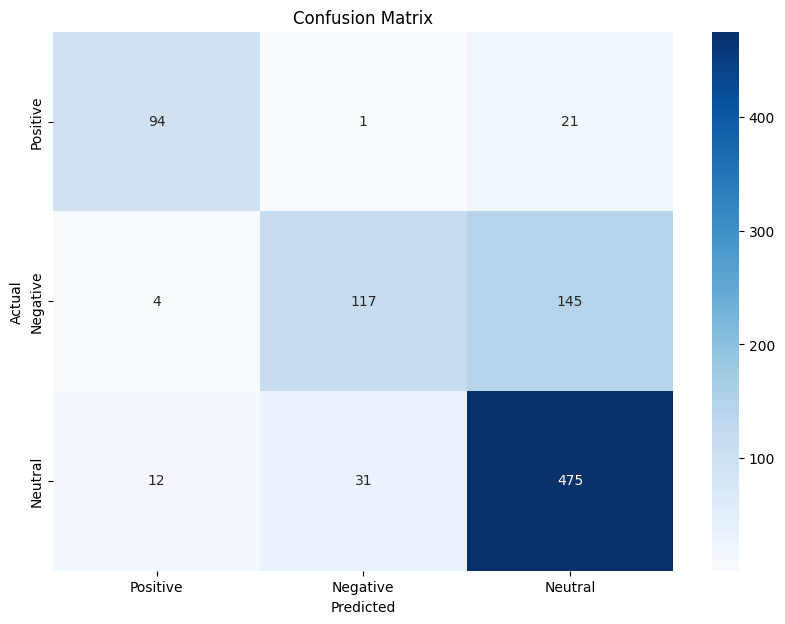

In [39]:
cm_svm = confusion_matrix(y_test, y_pred_gridsearch, labels = [2,1,0]) # confusion matrix. labels = [...] for consistent ordering across notebooks
plt.figure(figsize=(10,7))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', xticklabels=['Positive', 'Negative', 'Neutral'], yticklabels=['Positive', 'Negative', 'Neutral'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [27]:
actually_negative_wrong_neutral = pd.DataFrame(X_test[(y_test == 1) & (y_pred == 0)])
pd.set_option('display.max_colwidth', None)
actually_negative_wrong_neutral.sample(20)

,text
3679,Respektlos!
2542,Das hätten Sie früher sagen sollen!
3012,Dann macht doch mal was!
4017,"Ich mach mir die Welt, wie sie mir gefällt!"
297,Schön wäre es!
680,"Eine Straße ist nach ihm benannt! Hier um die Ecke! Das tut deinem Hirn gut, wenn da ein bisschen Luft reinkommt, und deinem Bauch auch!"
139,Was ist das denn für ein Eiertanz?
4393,"Jetzt werden Sie auch noch polemisch, Herr Meyer! Das steht Ihnen nicht gut an!"
144,Auch weil die Preise am Markt so hoch sind! Wenn Sie sich mal die Getreidepreise ansehen würden! Aber das tun Sie ja nicht!
3641,"Da bin ich aber gespannt, wie das im Agrarhaushalt gehen soll!"


"Waffen und Morde" wird hier als neutral eingestuft. Man merkt doch, dass hier kein vortrainiertes Sprachmodell oder Embeddings dahinter sind, sondern, dass nur die wirklich im Datensatz vorkommenden Informationen berücksichtigt werden.  
Das hat mich auf den in auch in der Vorlesung kurz besprochenen Ansatz gebracht, ein BERT-Modell als Embedding benutzen könnte.

# BERT-Embeddings x SVM

In [28]:
import torch
from transformers import BertTokenizer, BertModel
device = 'cuda'

c:\ProgFiles\PythonVenvs\nlpvenv2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html



In [29]:
tokenizer = BertTokenizer.from_pretrained('bert-base-german-cased')
model = BertModel.from_pretrained('bert-base-german-cased').to(device)

def get_bert_embeddings(text_list):
    embeddings = []
    for text in text_list:
        inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=512).to(device)
        outputs = model(**inputs)
        last_hidden_states = outputs.last_hidden_state.to('cpu')
        embeddings.append(last_hidden_states.mean(dim=1).detach().numpy().flatten())
    return embeddings

X_train_embeddings = get_bert_embeddings(X_train)
X_test_embeddings = get_bert_embeddings(X_test)

c:\ProgFiles\PythonVenvs\nlpvenv2\Lib\site-packages\transformers\models\bert\modeling_bert.py:435: UserWarning:

1Torch was not compiled with flash attention. (Triggered internally at ..\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:455.)



In [30]:
print(np.array(X_test_embeddings).shape)

(900, 768)


In [32]:
# training
svm_bert_emb = SVC(kernel='linear')
svm_bert_emb.fit(X_train_embeddings, y_train)

# prediction
y_pred_svm_bert = svm_bert_emb.predict(X_test_embeddings)


y_pred_svm_bert_txt = [id2label[x] for x in y_pred_svm_bert]

report_svm_bert = classification_report(y_test_txt, y_pred_svm_bert_txt )

In [33]:
print(report_svm_bert)

              precision    recall  f1-score   support

    negative       0.66      0.65      0.65       266
     neutral       0.79      0.79      0.79       518
    positive       0.77      0.84      0.80       116

    accuracy                           0.75       900
   macro avg       0.74      0.76      0.75       900
weighted avg       0.75      0.75      0.75       900



Die f1-scores sehen hier insgesamt am besten aus. Die negative Klasse wird zwar immer noch vergleichsweise schlecht erkannt.

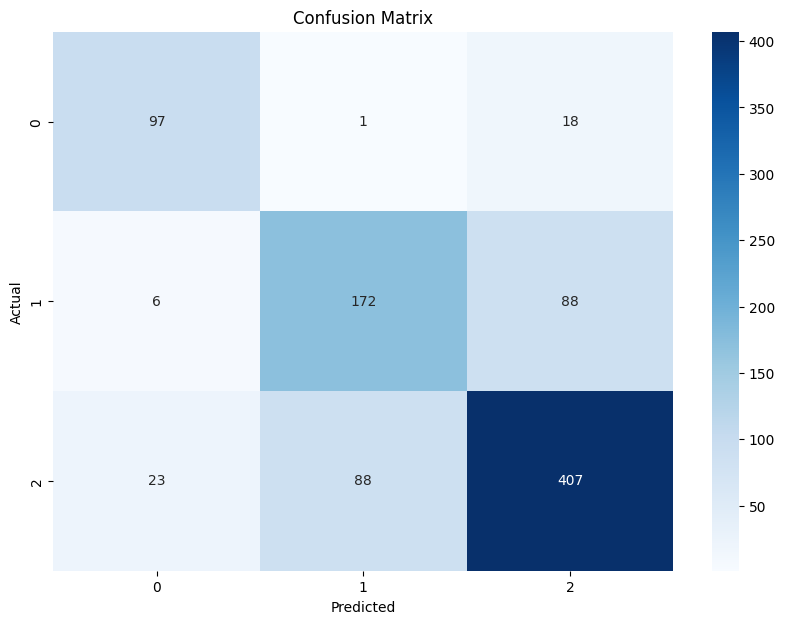

In [35]:
cm_svm_bert = confusion_matrix(y_test_txt, y_pred_svm_bert_txt, labels=['positive', 'negative', 'neutral'])
plt.figure(figsize=(10,7))
sns.heatmap(cm_svm_bert, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

An der Verwechslungsmatrix merkt man hier, dass die Fehler eigentlich immer in der Zuweisung neutral <-> negativ liegen. Genau die Zuweisung, bei der wir uns beim Labeln selbst schwergetan haben.  
Das BERT-Modell scheint also das im Vortraining erlangte Sprachverständnis durchaus miteinzubringen. 

### Grid search für die SVM mit BERT-Embeddings

Da die Laufzeit hier erheblich höher ist, habe ich die Parameterauswahl etwas eingeschränkt.

In [40]:
svm_bert_emb_gridsearch = SVC()

# fewer parameters than before to reduce train time
param_grid = {
    'kernel': ['linear', 'poly', 'rbf'], # perhaps our decision boundary is nonlinear
    'C': [0.1, 1, 10], # regularization parameter
    'gamma': [0.001, 0.01, 0.1], 
    'degree': [2, 3], # degree of the polynomial kernel
    'coef0': [0, 0.1, 1], # only for poly and sigmoid kernels, 
}


grid_search = GridSearchCV(svm_bert_emb_gridsearch, param_grid, cv = 2, scoring='accuracy', verbose=10, n_jobs=-1)
grid_search.fit(X_train_embeddings, y_train)

Fitting 2 folds for each of 162 candidates, totalling 324 fits


GridSearchCV(cv=2, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'coef0': [0, 0.1, 1],
                         'degree': [2, 3], 'gamma': [0.001, 0.01, 0.1],
                         'kernel': ['linear', 'poly', 'rbf']},
             scoring='accuracy', verbose=10)

In [41]:
# best parameters and estimator
best_params = grid_search.best_params_ 
svm_bert_emb_gridsearch = grid_search.best_estimator_

print("Best Parameters:", best_params)

y_pred_svm_bert_gridsearch= svm_bert_emb_gridsearch.predict(X_test_embeddings)
y_pred_svm_bert_gridsearch_txt = [id2label[x] for x in y_pred_svm_bert_gridsearch]

Best Parameters: {'C': 1, 'coef0': 0, 'degree': 2, 'gamma': 0.01, 'kernel': 'rbf'}


In [42]:
print(classification_report(y_test, y_pred_gridsearch,target_names=['neutral', 'negative', 'positive']))

              precision    recall  f1-score   support

     neutral       0.74      0.92      0.82       518
    negative       0.79      0.44      0.56       266
    positive       0.85      0.81      0.83       116

    accuracy                           0.76       900
   macro avg       0.79      0.72      0.74       900
weighted avg       0.77      0.76      0.75       900



Evaluation Gridsearch SVM mit BERT-Outputs als Embeddings:

Obwohl die Accuracy in dieser Konfiguration dem GridSearch-Trainer nach minimal höher (oder genau gleich) war als bei der SVM mit Standard-Parametern, ist der Recall für negative Samples deutlich zu schwach.  
Daher bewerte ich die SVM mit Standard-Parametern und BERT-Embeddings insgesamt als besser.

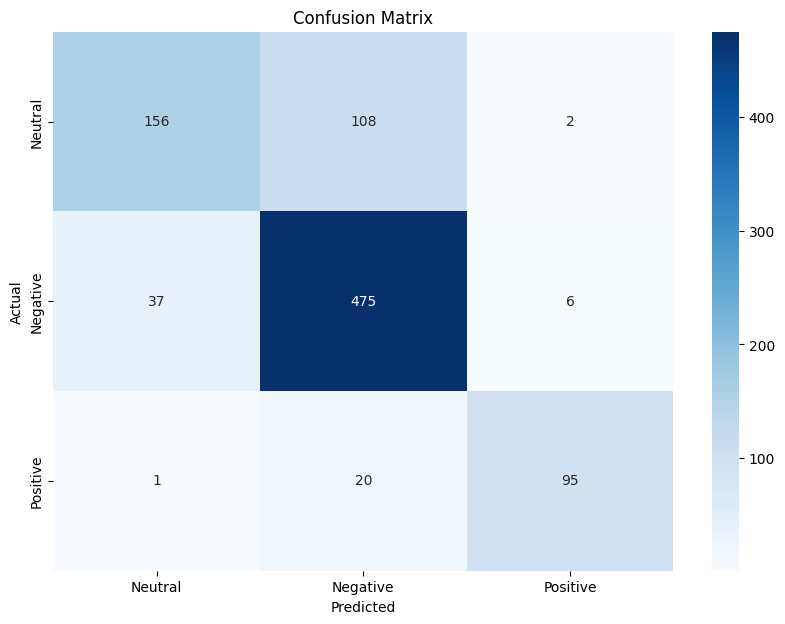

In [43]:
cm_svm_bert_emb_grid = confusion_matrix(y_test_txt, y_pred_svm_bert_gridsearch_txt)
plt.figure(figsize=(10,7))
sns.heatmap(cm_svm_bert_emb_grid, annot=True, fmt='d', cmap='Blues', xticklabels=['Neutral', 'Negative', 'Positive'], yticklabels=['Neutral', 'Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Evaluation Standard-Klassifikatoren

Vor allem die SVM bietet schon sinnvolle - noch nicht gute - Ergebnisse.  
Insgesamt scheinen unsere Daten aber schwierig klassifizierbar zu sein. Selbst mit BERT-Embeddings und dadurch zumindest etwas "Sprachverständnis" ging die Accuracy nie über 76% hinaus.  